# 🥑 Avocado Data Analysis & Machine Learning Project

## 📌 Introduction

Avocados (Avocado) have become one of the most popular agricultural products globally, driven by increasing awareness of their nutritional benefits and rising demand in modern diets. As consumption continues to grow, understanding the factors that influence avocado pricing and classification has become essential for producers, retailers, and data analysts.

This project focuses on exploring and analyzing avocado sales data to uncover meaningful patterns and build predictive models. The dataset includes information on avocado prices, sales volume, product types (organic and conventional), and distribution across different regions and time periods.

The analysis is divided into key components. First, a regression approach is used to investigate how various factors, particularly sales volume, influence the average price of avocados. This helps in understanding the economic relationship between supply and pricing. Next, a classification model is developed to distinguish between organic and conventional avocados using machine learning techniques such as Logistic Regression.

Additionally, the project explores the potential of time-based analysis to study trends and patterns in avocado prices over time, offering insights into seasonality and market behavior.

By combining data cleaning, exploratory data analysis, and machine learning techniques, this project demonstrates how data-driven approaches can be applied to real-world agricultural and economic problems.

In [132]:
# import libraries
import pandas as pd
import numpy as np
import janitor
import seaborn as sns
from ipywidgets import interact
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from plotnine import *

In [133]:
# load your dataset
avocado = pd.read_csv("C:/Users/user/Downloads/avocado.csv")
avocado.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,12/27/2015,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,12/20/2015,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,12/13/2015,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,12/6/2015,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,11/29/2015,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


# Part 1: Price Prediction 
Objective: Predict avocado prices using Linear Regression or time series

# Data cleaning

In [134]:
# data info 
avocado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  object 
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249 non-null  float64
 11  type          18249 non-null  object 
 12  year          18249 non-null  int64  
 13  region        18249 non-null  object 
dtypes: float64(9), int64(2), object(3)
memory usage: 1.9+ MB


In [135]:
avocado.skew(numeric_only = True)

Unnamed: 0       0.108334
AveragePrice     0.580303
Total Volume     9.007687
4046             8.648220
4225             8.942466
4770            10.159396
Total Bags       9.756072
Small Bags       9.540660
Large Bags       9.796455
XLarge Bags     13.139751
year             0.215339
dtype: float64

In [136]:
# fixing the column names
avocado2 = avocado.clean_names()
avocado2.head()

,unnamed_0,date,averageprice,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region
0,0,12/27/2015,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,12/20/2015,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,12/13/2015,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,12/6/2015,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,11/29/2015,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [137]:
# remove column unnamed

avocado2 = avocado2.drop(columns = ["unnamed_0"])
avocado2.head()

,date,averageprice,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region
0,12/27/2015,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,12/20/2015,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,12/13/2015,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,12/6/2015,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,11/29/2015,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [138]:
# fixing average price column
avocado2. rename(columns = {"averageprice" : "average_price"}, inplace = True)
avocado2.head()

,date,average_price,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region
0,12/27/2015,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,12/20/2015,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,12/13/2015,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,12/6/2015,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,11/29/2015,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [139]:
# Convert Date column to datetime format
avocado2["date"] = pd.to_datetime(avocado2["date"])
avocado2.head()

,date,average_price,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [140]:
# checking missing values
avocado2.isnull().sum()

date             0
average_price    0
total_volume     0
4046             0
4225             0
4770             0
total_bags       0
small_bags       0
large_bags       0
xlarge_bags      0
type             0
year             0
region           0
dtype: int64

In [141]:
# checking for duplicates
avocado2.duplicated().sum()

np.int64(0)

In [142]:
# Extract features such as month and year 
avocado2["month"] = avocado2["date"].dt.month
avocado2.head()

,date,average_price,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region,month
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany,12
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany,12
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany,12
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany,12
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany,11


In [143]:
# data describ

avocado2.describe()

,date,average_price,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,year,month
count,18249,18249.000000,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,18249.000000,18249.000000,18249.000000
mean,2016-08-13 23:30:43.498273792,1.405978,8.506440e+05,2.930084e+05,2.951546e+05,2.283974e+04,2.396392e+05,1.821947e+05,5.433809e+04,3106.426507,2016.147899,6.177215
min,2015-01-04 00:00:00,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2015.000000,1.000000
25%,2015-10-25 00:00:00,1.100000,1.083858e+04,8.540700e+02,3.008780e+03,0.000000e+00,5.088640e+03,2.849420e+03,1.274700e+02,0.000000,2015.000000,3.000000
50%,2016-08-14 00:00:00,1.370000,1.073768e+05,8.645300e+03,2.906102e+04,1.849900e+02,3.974383e+04,2.636282e+04,2.647710e+03,0.000000,2016.000000,6.000000
75%,2017-06-04 00:00:00,1.660000,4.329623e+05,1.110202e+05,1.502069e+05,6.243420e+03,1.107834e+05,8.333767e+04,2.202925e+04,132.500000,2017.000000,9.000000
max,2018-03-25 00:00:00,3.250000,6.250565e+07,2.274362e+07,2.047057e+07,2.546439e+06,1.937313e+07,1.338459e+07,5.719097e+06,551693.650000,2018.000000,12.000000
std,NaN,0.402677,3.453545e+06,1.264989e+06,1.204120e+06,1.074641e+05,9.862424e+05,7.461785e+05,2.439660e+05,17692.894652,0.939938,3.534130


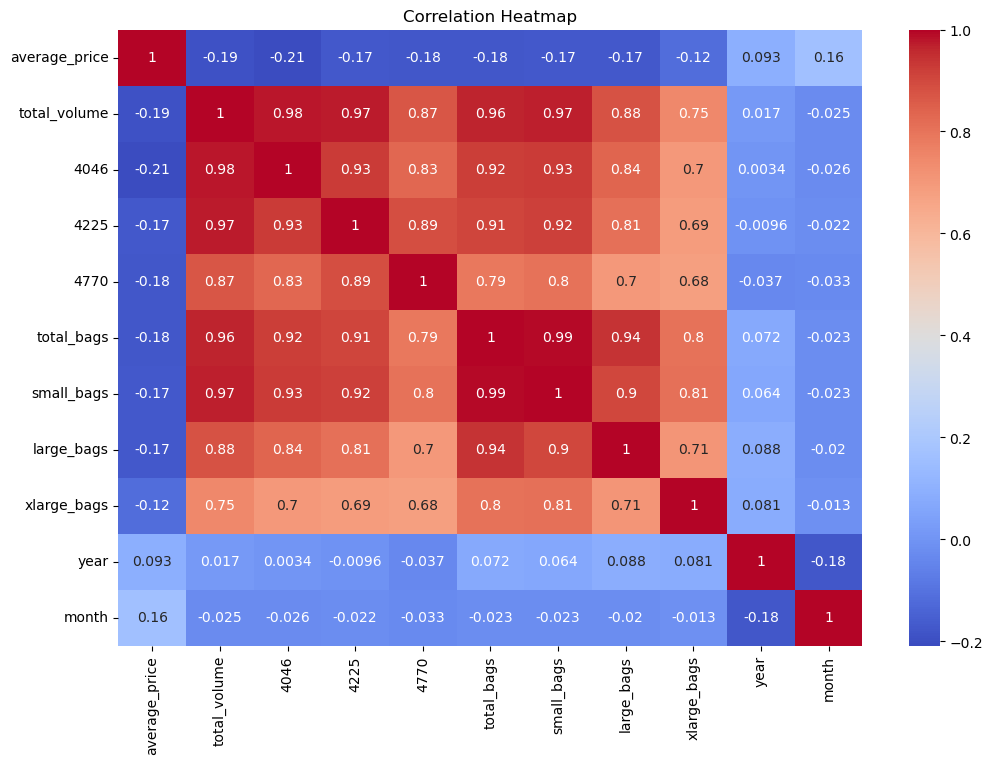

In [144]:
plt.figure(figsize=(12,8))
sns.heatmap(avocado2.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# interpretation 
The correlation heatmap shows that avocado price has a weak negative relationship with most numerical variables such as total volume and bag counts. This suggests that increases in supply slightly reduce price, although the relationship is not strong.

Additionally, there is a very high positive correlation among volume-related variables (e.g., total volume, PLU codes, and bag sizes), indicating multicollinearity. This means many features contain similar information, which can negatively affect regression model performance.

In [145]:
# data aggregate by yearly average price

yearly_average_price = avocado2.groupby("year")["average_price"].mean()
yearly_average_price 

year
2015    1.375590
2016    1.338640
2017    1.515128
2018    1.347531
Name: average_price, dtype: float64

In [146]:
# data aggregate by monthly average price

monthly_average_price = avocado2.groupby("month")["average_price"].mean()
monthly_average_price 

month
1     1.311019
2     1.274387
3     1.332255
4     1.374380
5     1.346601
6     1.408964
7     1.462077
8     1.512514
9     1.572654
10    1.579683
11    1.455563
12    1.331112
Name: average_price, dtype: float64

In [147]:
# data aggregate by region average price

region_average_price = avocado2.groupby("region")["average_price"].mean()
region_average_price

region
Albany                 1.561036
Atlanta                1.337959
BaltimoreWashington    1.534231
Boise                  1.348136
Boston                 1.530888
BuffaloRochester       1.516834
California             1.395325
Charlotte              1.606036
Chicago                1.556775
CincinnatiDayton       1.209201
Columbus               1.252781
DallasFtWorth          1.085592
Denver                 1.218580
Detroit                1.276095
GrandRapids            1.505000
GreatLakes             1.338550
HarrisburgScranton     1.513284
HartfordSpringfield    1.818639
Houston                1.047929
Indianapolis           1.313994
Jacksonville           1.510947
LasVegas               1.380917
LosAngeles             1.216006
Louisville             1.286686
MiamiFtLauderdale      1.428491
Midsouth               1.404763
Nashville              1.212101
NewOrleansMobile       1.304793
NewYork                1.727574
Northeast              1.601923
NorthernNewEngland     1.477396
O

# Data Exploration

In [148]:
avocado2.head()

,date,average_price,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region,month
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany,12
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany,12
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany,12
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany,12
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany,11


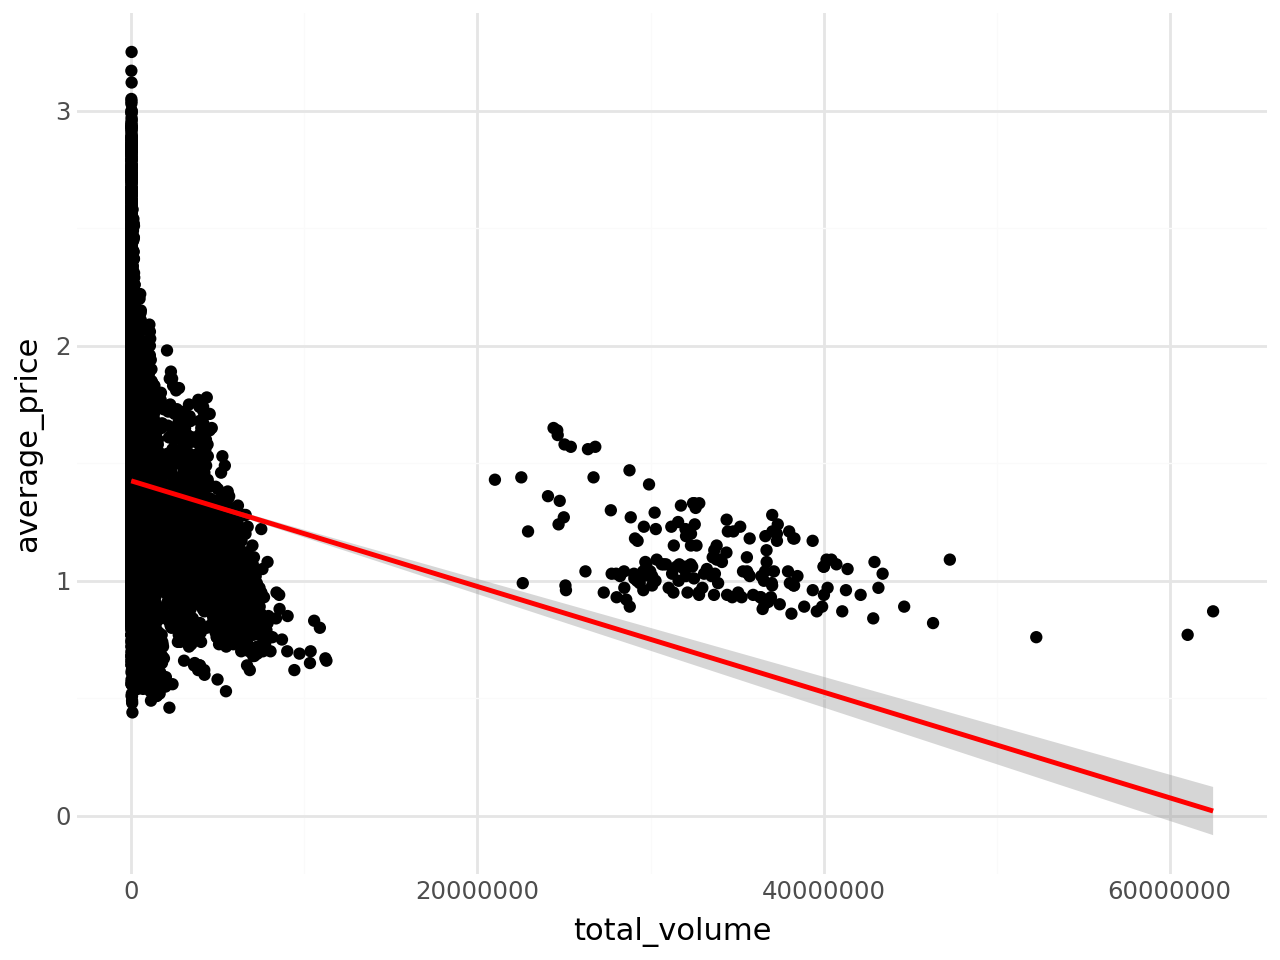

In [149]:
(ggplot (avocado2, aes("total_volume", "average_price"))
 + geom_point()
 + geom_smooth(color = "red")
 + theme_minimal()
)

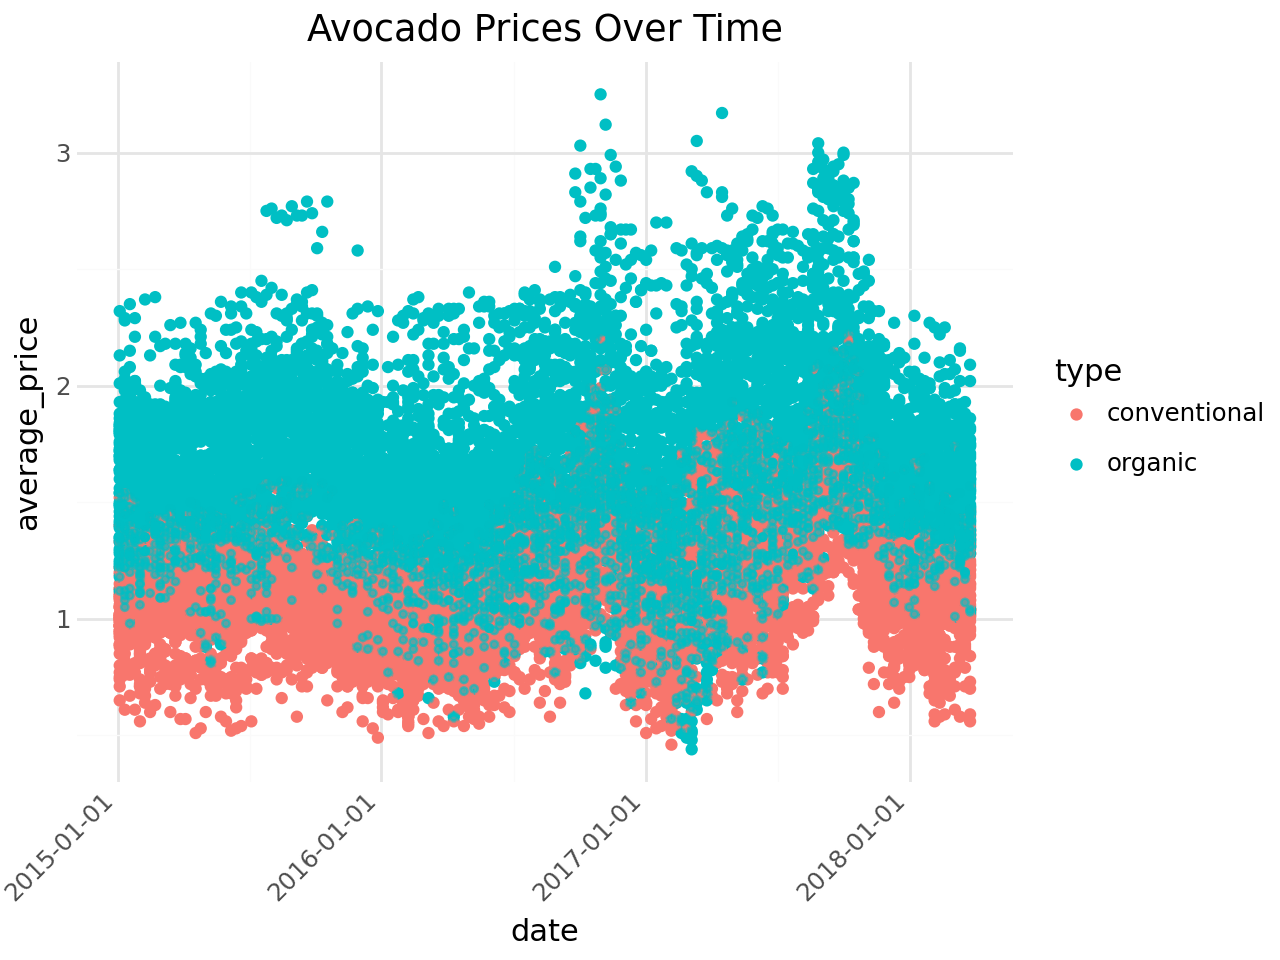

In [273]:
(ggplot(avocado2, aes("date", "average_price", color="type"))
 + geom_point()
 + geom_point(size=1, alpha=0.6) 
 + labs(title="Avocado Prices Over Time")
 + theme_minimal() 
 + theme(axis_text_x=element_text(rotation=45, hjust=1))
)

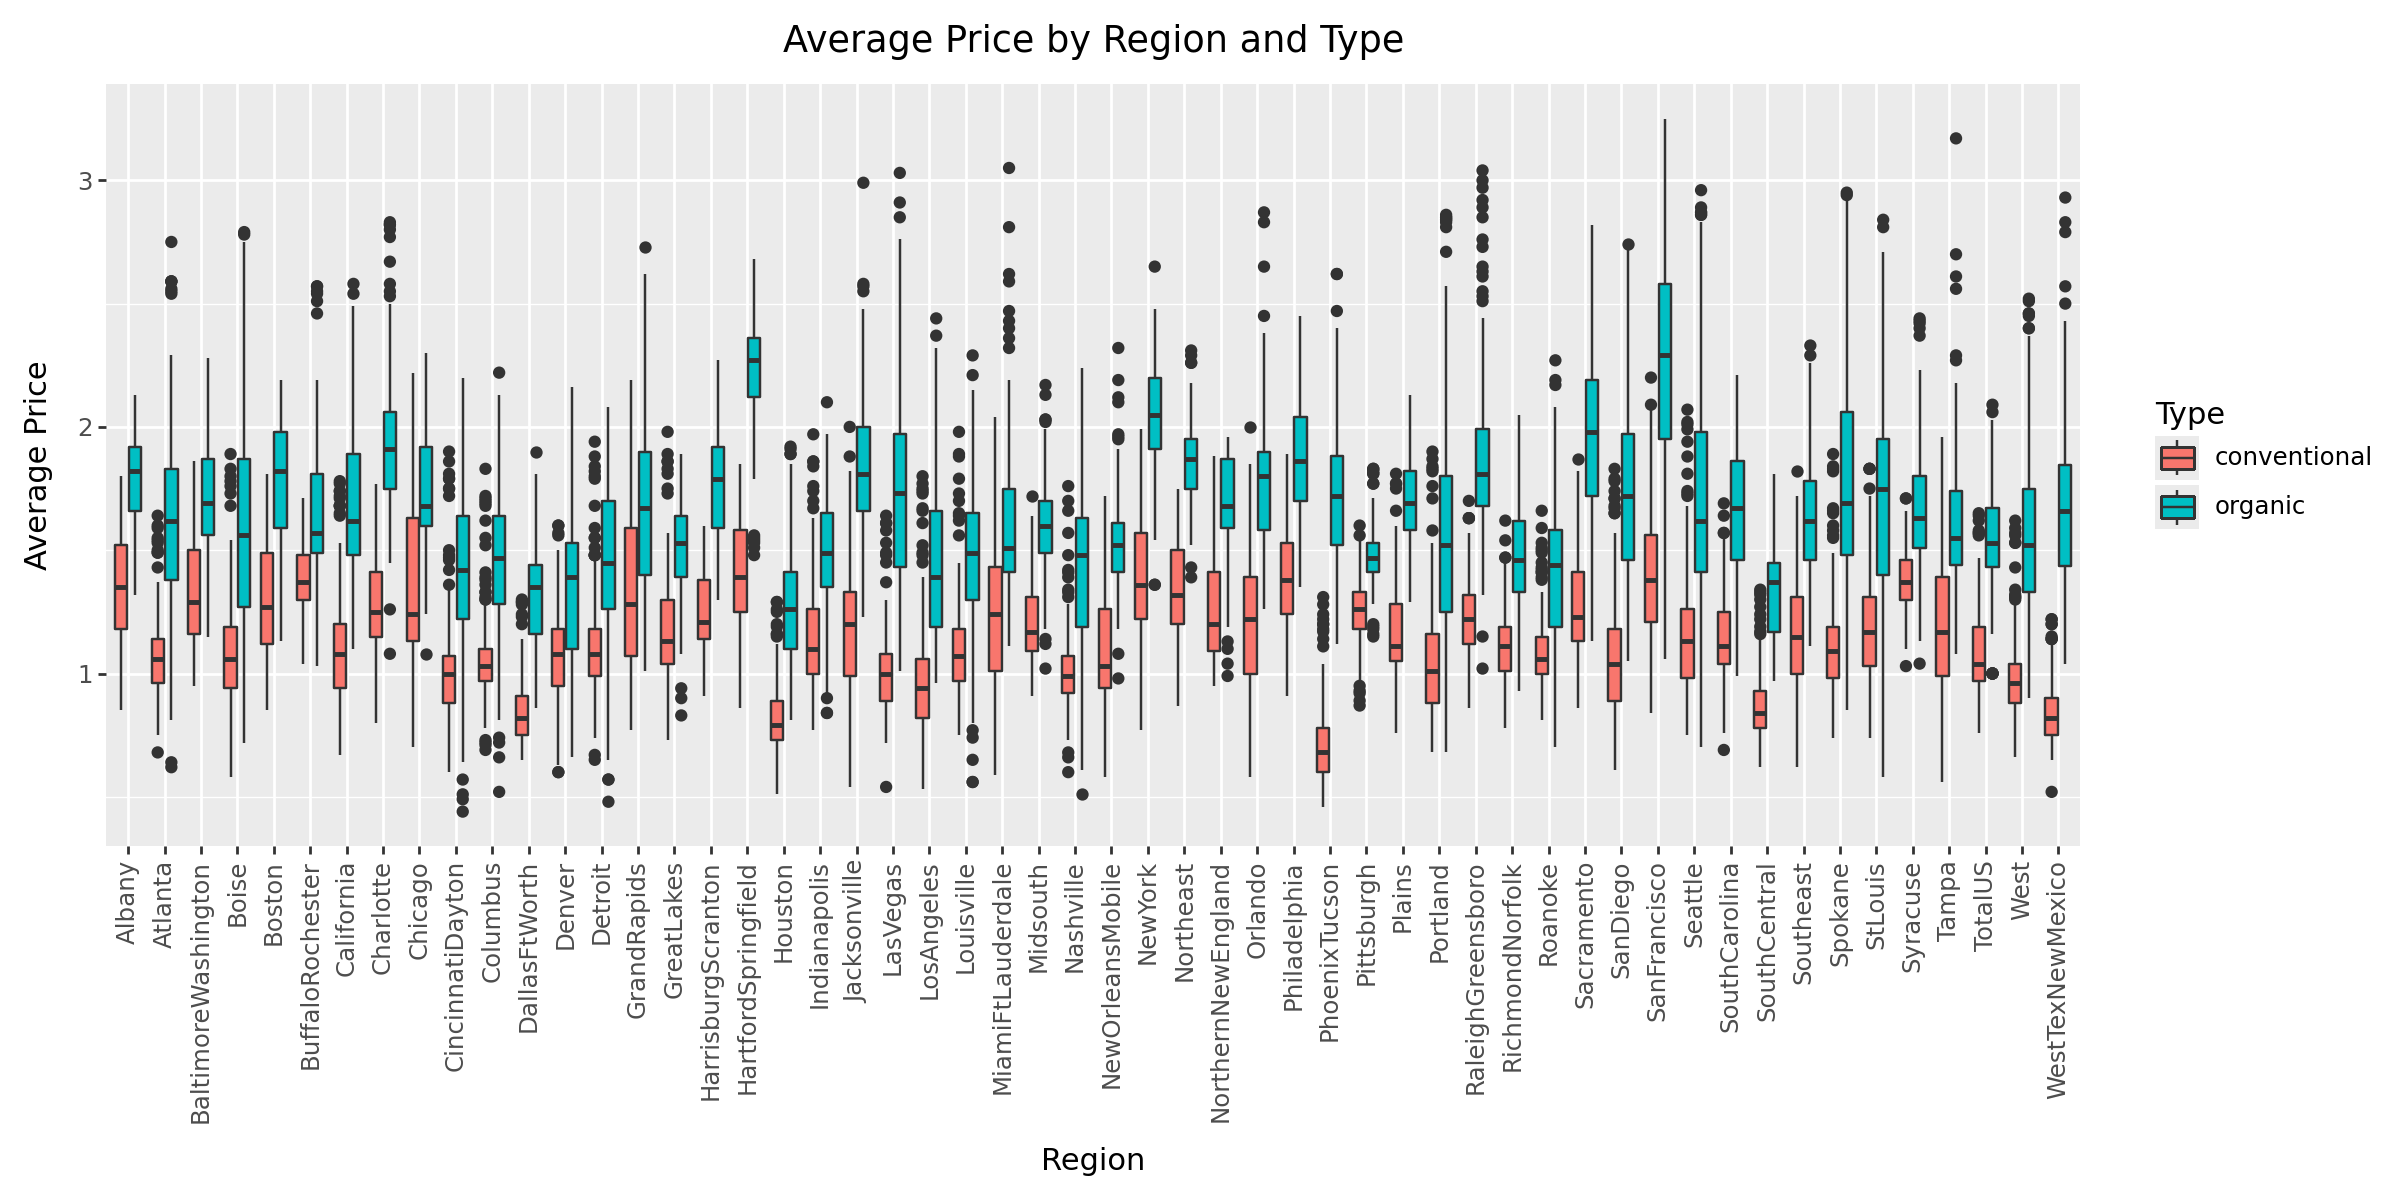

In [287]:
(ggplot(avocado2, aes("region", "average_price", fill="type"))
 + geom_boxplot()
 + labs(title='Average Price by Region and Type',
       x = "Region",
       y = "Average Price",
       fill = "Type")
 + theme(axis_text_x=element_text(rotation=90), figure_size =(12, 6))
)

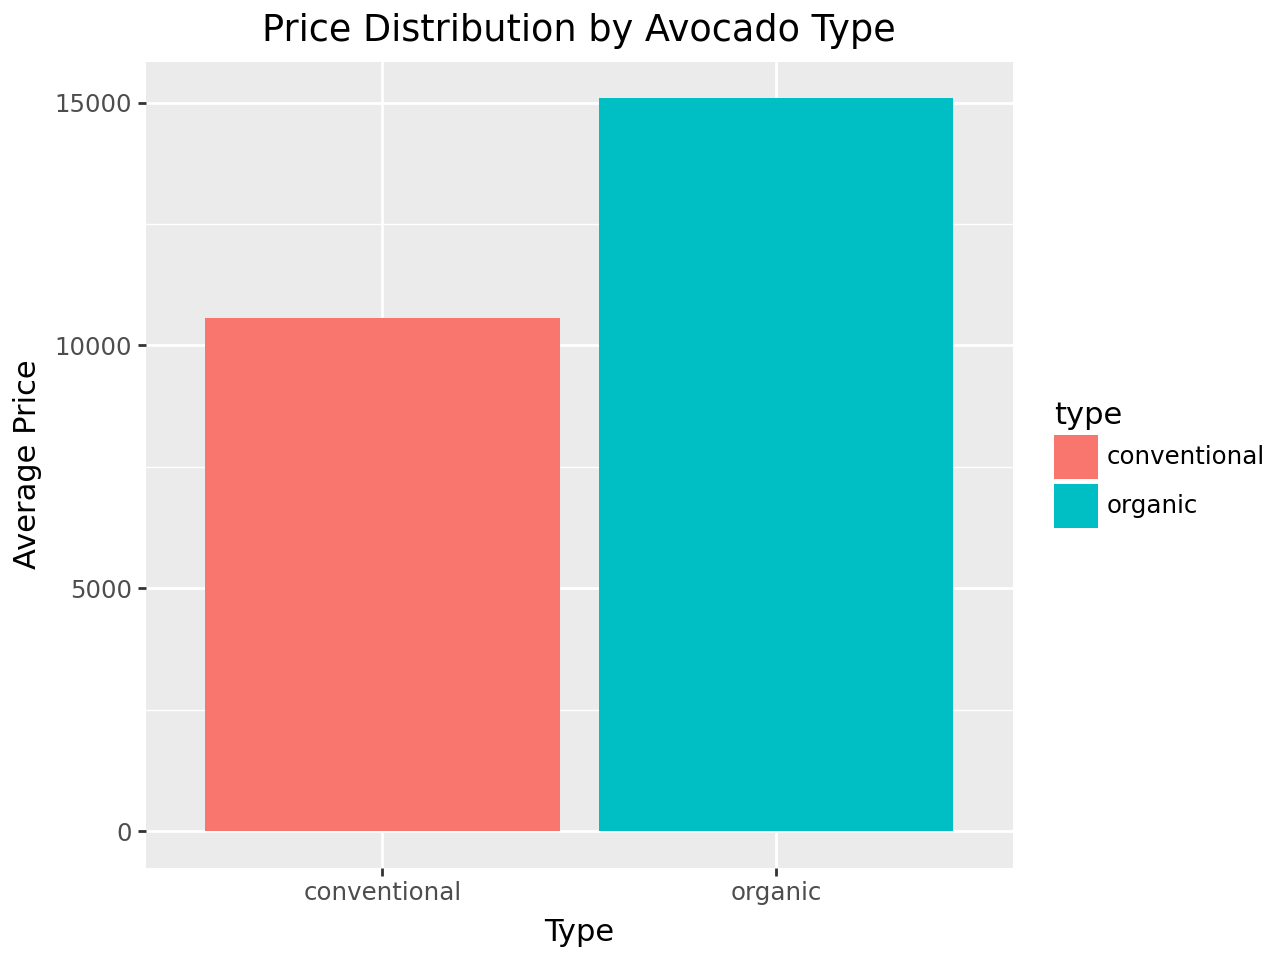

In [286]:
(ggplot(avocado2, aes(x= "type", y= "average_price", fill= "type"))
 + geom_col()
 + labs(title="Price Distribution by Avocado Type",
        x='Type',
        y='Average Price'))

# Data Preprocessing

In [153]:
# selecting relevant features 
avocado2 = avocado2.drop(["small_bags", "large_bags", "xlarge_bags"], axis = 1)
avocado2.head()

,date,average_price,total_volume,4046,4225,4770,total_bags,type,year,region,month
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,conventional,2015,Albany,12
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,conventional,2015,Albany,12
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,conventional,2015,Albany,12
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,conventional,2015,Albany,12
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,conventional,2015,Albany,11


# Simple Linear Regression

In [154]:
from sklearn.model_selection import train_test_split

#independent_variables 

independent_variables = avocado2.drop("average_price", axis =1)
independent_variables.head()

,date,total_volume,4046,4225,4770,total_bags,type,year,region,month
0,2015-12-27,64236.62,1036.74,54454.85,48.16,8696.87,conventional,2015,Albany,12
1,2015-12-20,54876.98,674.28,44638.81,58.33,9505.56,conventional,2015,Albany,12
2,2015-12-13,118220.22,794.70,109149.67,130.50,8145.35,conventional,2015,Albany,12
3,2015-12-06,78992.15,1132.00,71976.41,72.58,5811.16,conventional,2015,Albany,12
4,2015-11-29,51039.60,941.48,43838.39,75.78,6183.95,conventional,2015,Albany,11


In [155]:
# dependent_variables

dependent_variable = avocado2["average_price"]
dependent_variable.head()

0    1.33
1    1.35
2    0.93
3    1.08
4    1.28
Name: average_price, dtype: float64

In [156]:
# Split data into training and testing sets 

x_train, x_test, y_train, y_test = train_test_split(independent_variables, dependent_variable, test_size = 0.2, random_state = 42)

In [157]:
x_train.shape

(14599, 10)

In [158]:
x_test.shape

(3650, 10)

In [159]:
y_test.shape

(3650,)

In [160]:
y_train.shape

(14599,)

# Initiate and train the model

In [161]:
x_total_volume = x_train[['total_volume']]
x_total_volume.head()

,total_volume
16391,5376.58
4990,578610.94
13653,6470.08
2074,145648.40
12377,40535.05


In [162]:
from sklearn.linear_model import LinearRegression
avocado_model = LinearRegression()
avocado_model.fit(x_total_volume, y_train)

LinearRegression()

# Model Parameters

In [163]:
avocado_model.intercept_

np.float64(1.424440591389887)

In [164]:
avocado_model.coef_

array([-2.30730822e-08])

In [165]:
pd.DataFrame(avocado_model.coef_, x_total_volume.columns, ["coefficient"])

,coefficient
total_volume,-2.307308e-08


In [166]:
# price prediction 


price_pred = avocado_model.predict(x_total_volume)
price_pred[0:10]

array([1.42431654, 1.41109025, 1.42429131, 1.42108003, 1.42350532,
       1.41806269, 1.42438511, 1.41758945, 1.4199708 , 1.41777577])

# Evaluate the Model

In [167]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [168]:
r2 = r2_score(y_train, price_pred)
r2

0.03797394524203135

In [169]:
mse = mean_squared_error(y_train, price_pred)
mse

0.15633010297957298

In [170]:
rmse = np.sqrt(mse)
rmse

np.float64(0.39538601768344434)

# Multiple Linear Regression
## training with 2 features

In [171]:
x2 = x_train[['total_volume', 'type']]
x2.head()

,total_volume,type
16391,5376.58,organic
4990,578610.94,conventional
13653,6470.08,organic
2074,145648.40,conventional
12377,40535.05,organic


In [172]:
# encoding type column
x2= pd.get_dummies(x2, columns=["type"], drop_first=True, dtype = int)
x2

,total_volume,type_organic
16391,5376.58,1
4990,578610.94,0
13653,6470.08,1
2074,145648.40,0
12377,40535.05,1
...,...,...
11284,12946.65,1
11964,1193.06,1
5390,83407.69,0
860,277578.88,0


# Initiate and train the model

In [173]:
from sklearn.linear_model import LinearRegression
avocado_model2 = LinearRegression()
avocado_model2.fit(x2, y_train)

LinearRegression()

In [174]:
avocado_model2.intercept_

np.float64(1.1656409756082318)

In [175]:
avocado_model2.coef_

array([-6.18869940e-09,  4.89377587e-01])

In [176]:
pd.DataFrame(avocado_model2.coef_, x2.columns, ["Coefficients"])

,Coefficients
total_volume,-6.188699e-09
type_organic,4.893776e-01


# MODEL EVALUATION

In [177]:
avocado_pred2 = avocado_model2.predict(x2)
avocado_pred2[0:10]

array([1.65498529, 1.16206013, 1.65497852, 1.1647396 , 1.6547677 ,
       1.16393028, 1.65500368, 1.16380335, 1.16444208, 1.16385333])

In [178]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2_score(y_train, avocado_pred2)
r2

0.03797394524203135

In [179]:
mse = mean_squared_error(y_train, avocado_pred2)
mse

0.09976200589212288

In [180]:
rmse = np.sqrt(mse)
rmse

np.float64(0.31585124013073446)

# training with 3 features

In [181]:
x3 = x_train[['total_volume', 'type', "month"]]
x3.head()

,total_volume,type,month
16391,5376.58,organic,11
4990,578610.94,conventional,1
13653,6470.08,organic,11
2074,145648.40,conventional,2
12377,40535.05,organic,6


In [182]:
# encoding type and region
x3= pd.get_dummies(x3, columns=["type"], drop_first=True, dtype = int)
x3

,total_volume,month,type_organic
16391,5376.58,11,1
4990,578610.94,1,0
13653,6470.08,11,1
2074,145648.40,2,0
12377,40535.05,6,1
...,...,...,...
11284,12946.65,6,1
11964,1193.06,5,1
5390,83407.69,5,0
860,277578.88,6,0


# Initiate and train the model

In [183]:
from sklearn.linear_model import LinearRegression
avocado_model3 = LinearRegression()
avocado_model3.fit(x3, y_train)

LinearRegression()

In [184]:
avocado_model3.intercept_

np.float64(1.0530661574150182)

In [185]:
avocado_model3.coef_

array([-5.79330094e-09,  1.79981863e-02,  4.90824885e-01])

In [186]:
pd.DataFrame(avocado_model3.coef_, x3.columns, ["Coefficients"])

,Coefficients
total_volume,-5.793301e-09
month,1.799819e-02
type_organic,4.908249e-01


# MODEL EVALUATION

In [187]:
avocado_pred3 = avocado_model3.predict(x3)
avocado_pred3[0:10]

array([1.74183994, 1.06771228, 1.74183361, 1.08821874, 1.65164533,
       1.14145569, 1.70586079, 1.08734231, 1.24992391, 1.2133764 ])

In [188]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2_score(y_train, avocado_pred3)
r2

0.03797394524203135

In [189]:
mse = mean_squared_error(y_train, avocado_pred3)
mse

0.09572573192165956

In [190]:
rmse = np.sqrt(mse)
rmse

np.float64(0.30939575291470883)

# Log Transformation

The dataset contains several numerical features, such as avocado sales volumes (4046, 4225, 4770) and Total Bags, which are highly skewed. This skewness can negatively affect the performance of machine learning models by giving too much influence to extreme values.

To address this, a log transformation was applied to these features. This helps to reduce skewness, stabilize variance, and improve the relationship between the independent variables and the target variable (Average Price). The target variable itself was not transformed in this case.

In [191]:
avocado2.skew(numeric_only = True)

average_price     0.580303
total_volume      9.007687
4046              8.648220
4225              8.942466
4770             10.159396
total_bags        9.756072
year              0.215339
month             0.106617
dtype: float64

In [192]:
avocado3 = avocado2.copy()
avocado3.head()

,date,average_price,total_volume,4046,4225,4770,total_bags,type,year,region,month
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,conventional,2015,Albany,12
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,conventional,2015,Albany,12
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,conventional,2015,Albany,12
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,conventional,2015,Albany,12
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,conventional,2015,Albany,11


In [193]:
import numpy as np

cols = ["4046", "4225", "4770", "total_bags", "total_volume"]

for col in cols:
    avocado3[col] = np.log1p(avocado3[col])

avocado3.head()


,date,average_price,total_volume,4046,4225,4770,total_bags,type,year,region,month
0,2015-12-27,1.33,11.070344,6.944801,10.905146,3.895080,9.070833,conventional,2015,Albany,12
1,2015-12-20,1.35,10.912867,6.515127,10.706381,4.083115,9.159737,conventional,2015,Albany,12
2,2015-12-13,0.93,11.680313,6.679222,11.600485,4.879007,9.005325,conventional,2015,Albany,12
3,2015-12-06,1.08,11.277116,7.032624,11.184108,4.298373,8.667708,conventional,2015,Albany,12
4,2015-11-29,1.28,10.840377,6.848515,10.688288,4.340944,8.729874,conventional,2015,Albany,11


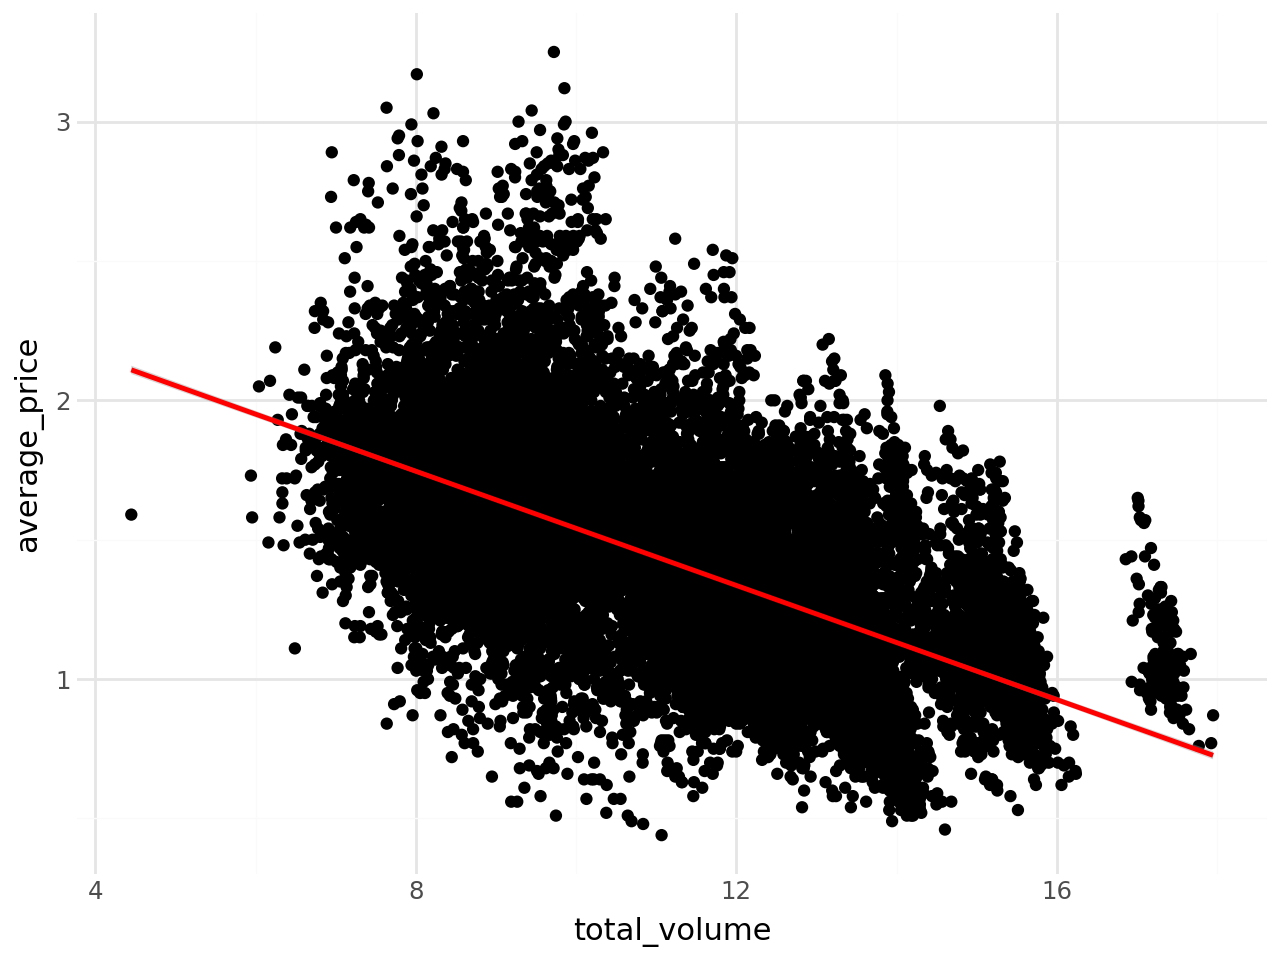

In [194]:
(ggplot (avocado3, aes("total_volume", "average_price"))
 + geom_point()
 + geom_smooth(color= "red")
 + theme_minimal()
)

In [195]:
# creating independent and dependent variables


independent_variables = avocado3.drop("average_price", axis =1)
independent_variables.head()

,date,total_volume,4046,4225,4770,total_bags,type,year,region,month
0,2015-12-27,11.070344,6.944801,10.905146,3.895080,9.070833,conventional,2015,Albany,12
1,2015-12-20,10.912867,6.515127,10.706381,4.083115,9.159737,conventional,2015,Albany,12
2,2015-12-13,11.680313,6.679222,11.600485,4.879007,9.005325,conventional,2015,Albany,12
3,2015-12-06,11.277116,7.032624,11.184108,4.298373,8.667708,conventional,2015,Albany,12
4,2015-11-29,10.840377,6.848515,10.688288,4.340944,8.729874,conventional,2015,Albany,11


In [196]:
dependent_variable = avocado3["average_price"]
dependent_variable.head()

0    1.33
1    1.35
2    0.93
3    1.08
4    1.28
Name: average_price, dtype: float64

In [197]:
# spliting my data

x_train, x_test, y_train, y_test = train_test_split(independent_variables, dependent_variable, test_size = 0.2, random_state = 42)

In [198]:
x_train.shape

(14599, 10)

In [199]:
x_test.shape

(3650, 10)

In [200]:
# model 
x_total_volume = x_train[['total_volume']]
x_total_volume.head()

,total_volume
16391,8.589994
4990,13.268387
13653,8.775098
2074,11.888958
12377,10.609947


In [201]:
from sklearn.linear_model import LinearRegression
avocado_model4 = LinearRegression()
avocado_model4.fit(x_total_volume, y_train)

LinearRegression()

In [202]:
avocado_model4.intercept_

np.float64(2.5772564195080303)

In [203]:
avocado_model4.coef_

array([-0.10354539])

In [204]:
pd.DataFrame(avocado_model4.coef_, x_total_volume.columns, ["coefficient"])

,coefficient
total_volume,-0.103545


In [205]:
# price prediction 

price_pred4 = avocado_model4.predict(x_total_volume)
price_pred4[0:10]

array([1.68780213, 1.20337602, 1.6686354 , 1.34620961, 1.47864527,
       1.27986502, 1.77109551, 1.27245375, 1.31667502, 1.27530862])

In [206]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [207]:
r2 = r2_score(y_train, price_pred4)
r2

0.3464863595505444

In [208]:
mse = mean_squared_error(y_train, price_pred)
mse

0.15633010297957298

In [209]:
rmse = np.sqrt(mse)
rmse

np.float64(0.39538601768344434)

# Multiple Linear Regression

In [210]:
x2 = x_train[['total_volume', 'type']]
x2.head()

,total_volume,type
16391,8.589994,organic
4990,13.268387,conventional
13653,8.775098,organic
2074,11.888958,conventional
12377,10.609947,organic


In [211]:
# encoding type column
x2= pd.get_dummies(x2, columns=["type"], drop_first=True, dtype = int)
x2

,total_volume,type_organic
16391,8.589994,1
4990,13.268387,0
13653,8.775098,1
2074,11.888958,0
12377,10.609947,1
...,...,...
11284,9.468670,1
11964,7.085115,1
5390,11.331508,0
860,12.533864,0


In [212]:
from sklearn.linear_model import LinearRegression
avocado_model5 = LinearRegression()
avocado_model5.fit(x2, y_train)

LinearRegression()

In [213]:
avocado_model5.intercept_

np.float64(1.7590303535155833)

In [214]:
avocado_model5.coef_

array([-0.04591534,  0.33171065])

In [215]:
pd.DataFrame(avocado_model5.coef_, x2.columns, ["Coefficients"])

,Coefficients
total_volume,-0.045915
type_organic,0.331711


In [216]:
avocado_pred5 = avocado_model5.predict(x2)
avocado_pred5[0:10]

array([1.69632855, 1.14980789, 1.68782941, 1.21314487, 1.60358172,
       1.18372556, 1.7332635 , 1.18043916, 1.20004829, 1.1817051 ])

In [217]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2_score(y_train, avocado_pred5)
r2

0.3464863595505444

In [218]:
mse = mean_squared_error(y_train, avocado_pred2)
mse

0.09976200589212288

In [219]:
rmse = np.sqrt(mse)
rmse

np.float64(0.31585124013073446)

# ✅ 📄 Final Conclusion

#  Conclusion on Price Prediction Models

In this study, four regression models were developed to predict avocado prices using both single and multiple linear regression approaches.

In the first stage, models were trained using the original (untransformed) data. Both the single linear regression model (using Total Volume as the only feature) and the multiple linear regression model produced a low R² value of 0.0379, indicating that the models were unable to effectively explain the variation in avocado prices. This suggests that the relationship between the features and the target variable is weak or not purely linear in its original form.

In the second stage, log transformation was applied to the feature variables to address skewness and improve data distribution. After this transformation, both the single and multiple regression models showed a significant improvement, achieving an R² value of 0.3464. This indicates that the transformed features provided a better representation of the underlying patterns in the data, leading to improved model performance.

However, the identical R² values for both single and multiple regression models suggest that adding more features did not significantly enhance predictive power. This may be due to multicollinearity among the features or the limited ability of linear models to capture complex relationships in the dataset.

Overall, the results demonstrate that log transformation plays a crucial role in improving model performance when dealing with skewed data. Nevertheless, the relatively moderate R² value indicates that additional factors not included in the model may influence avocado prices, and more advanced models could be explored for better prediction accuracy.

# TIME SERIES ANALYSIS

In [220]:
avocado2.head()

,date,average_price,total_volume,4046,4225,4770,total_bags,type,year,region,month
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,conventional,2015,Albany,12
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,conventional,2015,Albany,12
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,conventional,2015,Albany,12
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,conventional,2015,Albany,12
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,conventional,2015,Albany,11


# SELECT VARIABLES

In [221]:
avocado_price = avocado2[["date", "average_price"]]

In [222]:
avocado_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           18249 non-null  datetime64[ns]
 1   average_price  18249 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 285.3 KB


In [223]:
avocado_price.head()

,date,average_price
0,2015-12-27,1.33
1,2015-12-20,1.35
2,2015-12-13,0.93
3,2015-12-06,1.08
4,2015-11-29,1.28


 # CONVERSION

In [224]:
avocado_price["date"] = pd.to_datetime(avocado_price["date"], format='%m/%d/%Y')

C:\Users\user\AppData\Local\Temp\ipykernel_13476\3523805311.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [225]:
avocado_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           18249 non-null  datetime64[ns]
 1   average_price  18249 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 285.3 KB


In [226]:
avocado_price = avocado_price.set_index("date")

In [227]:
avocado_price.head()

,average_price
date,
2015-12-27,1.33
2015-12-20,1.35
2015-12-13,0.93
2015-12-06,1.08
2015-11-29,1.28


In [228]:
avocado_monthly = avocado_price["average_price"].resample("ME").agg(["sum", "mean", "count"])

In [229]:
avocado_monthly.head()

,sum,mean,count
date,,,
2015-01-31,589.70,1.365046,432
2015-02-28,573.24,1.326944,432
2015-03-31,735.47,1.361981,540
2015-04-30,597.65,1.383449,432
2015-05-31,726.13,1.344685,540


In [230]:
avocado_monthly_2 = avocado_monthly.reset_index()
avocado_monthly_2.head()

,date,sum,mean,count
0,2015-01-31,589.70,1.365046,432
1,2015-02-28,573.24,1.326944,432
2,2015-03-31,735.47,1.361981,540
3,2015-04-30,597.65,1.383449,432
4,2015-05-31,726.13,1.344685,540


 # LINEARITY

In [231]:
print(type(avocado_monthly_2))

<class 'pandas.core.frame.DataFrame'>


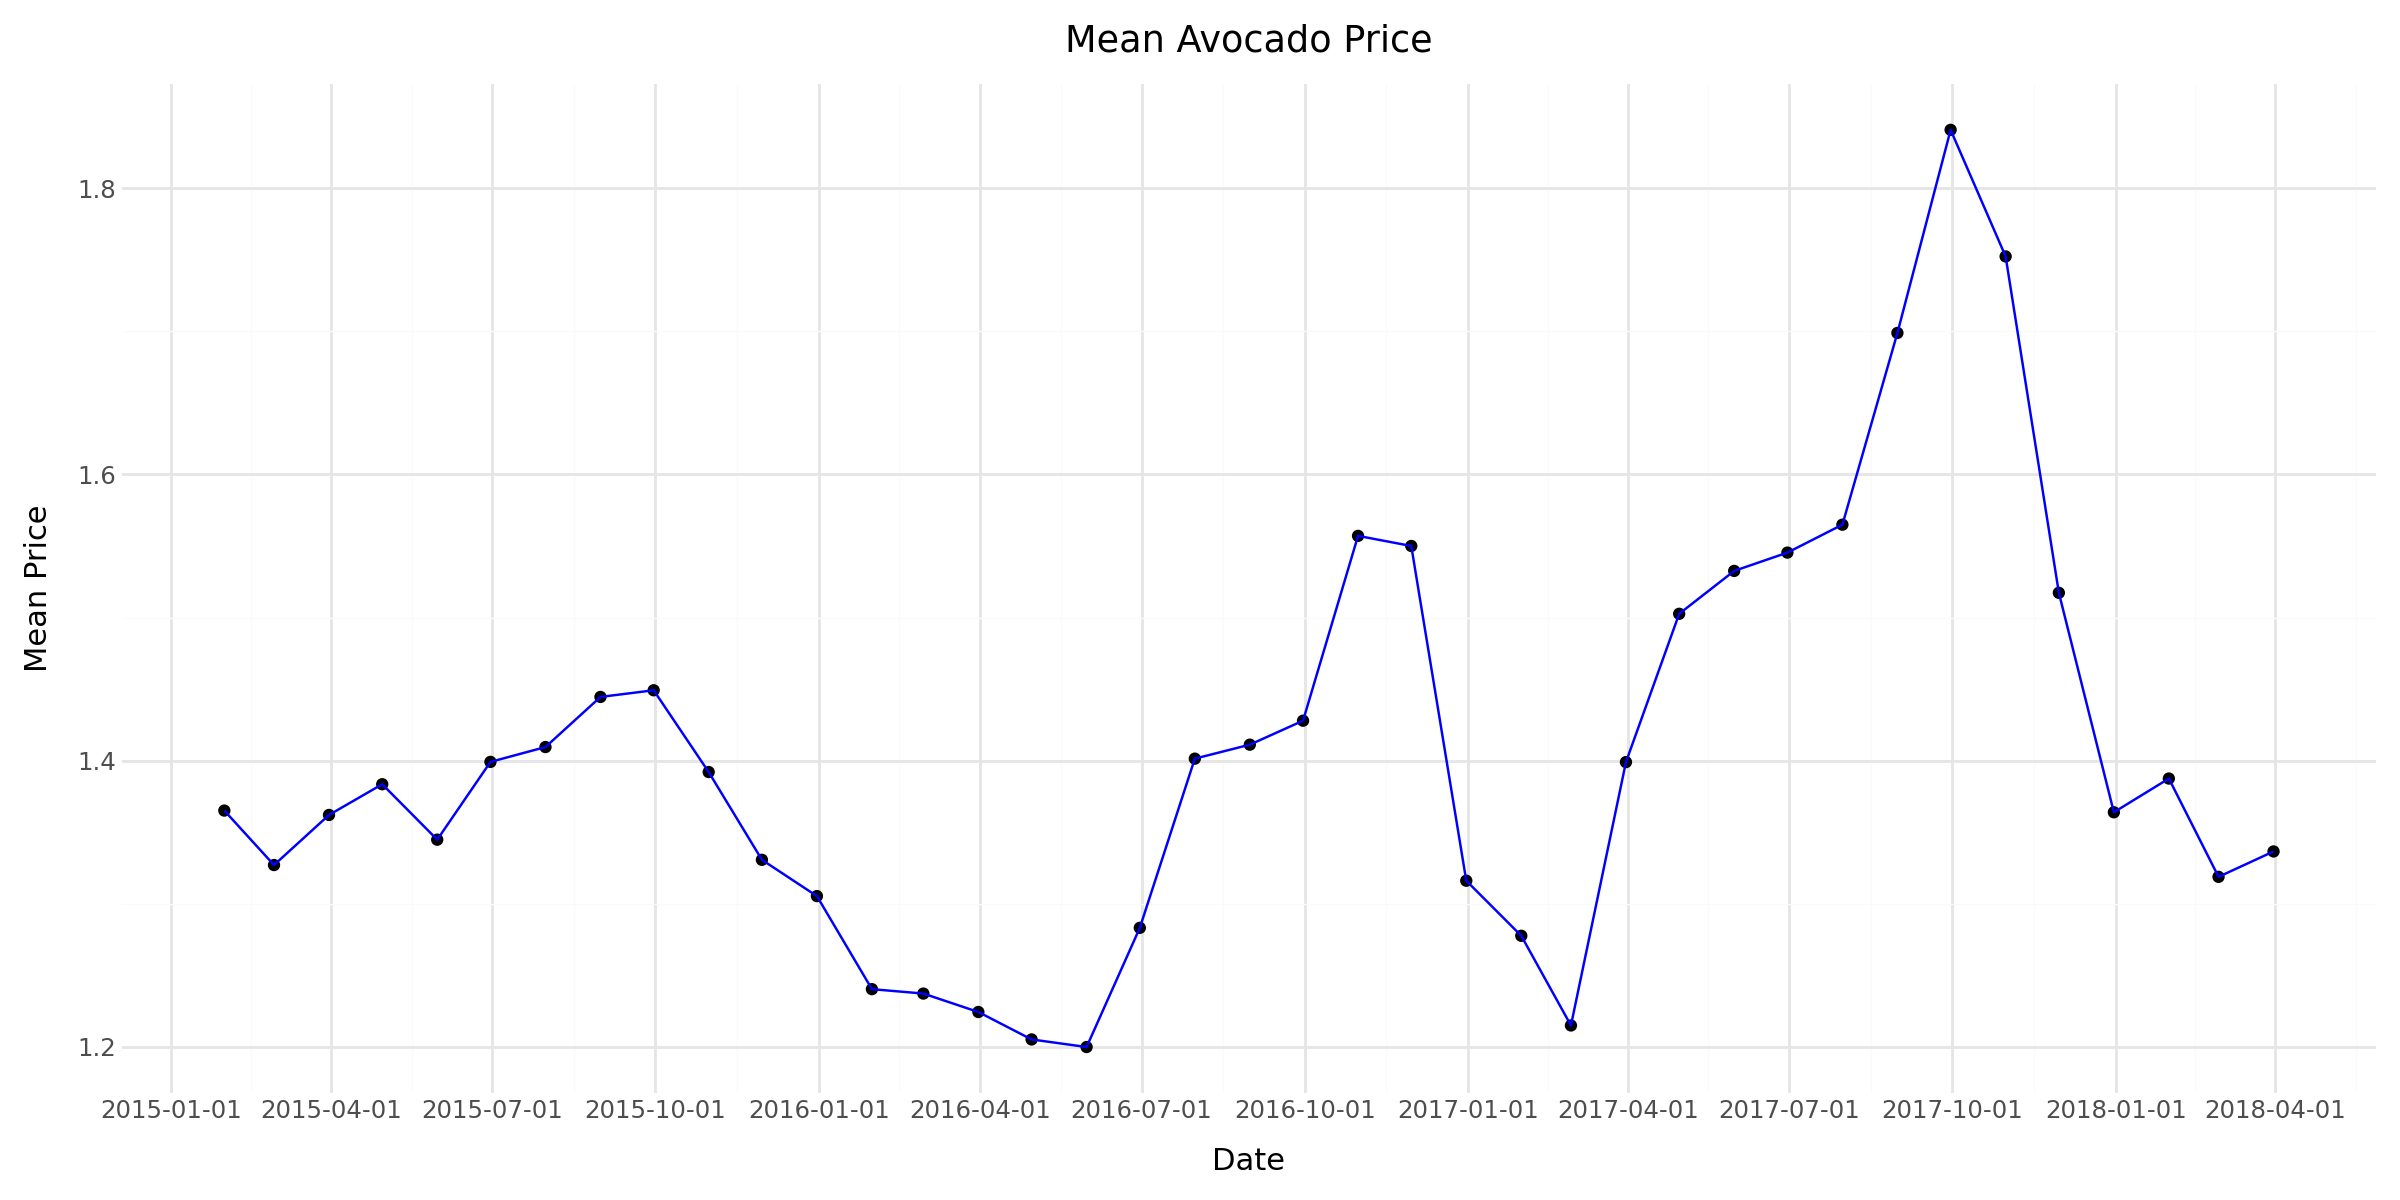

In [232]:
(ggplot(avocado_monthly_2, aes("avocado_monthly.index", "mean"))
+ geom_point()
+ geom_line(color = "blue")
+ theme_minimal()
+ theme(figure_size = (12, 6)) 
+ scale_x_datetime(date_breaks = "3 months")
+ labs(x = "Date",
       y = "Mean Price",
       title = "Mean Avocado Price"))

In [233]:
avocado_monthly["shift"] = avocado_monthly["mean"].shift(1)

In [234]:
avocado_monthly.head()

,sum,mean,count,shift
date,,,,
2015-01-31,589.70,1.365046,432,NaN
2015-02-28,573.24,1.326944,432,1.365046
2015-03-31,735.47,1.361981,540,1.326944
2015-04-30,597.65,1.383449,432,1.361981
2015-05-31,726.13,1.344685,540,1.383449


C:\Users\user\anaconda3\Lib\site-packages\plotnine\stats\smoothers.py:342: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.


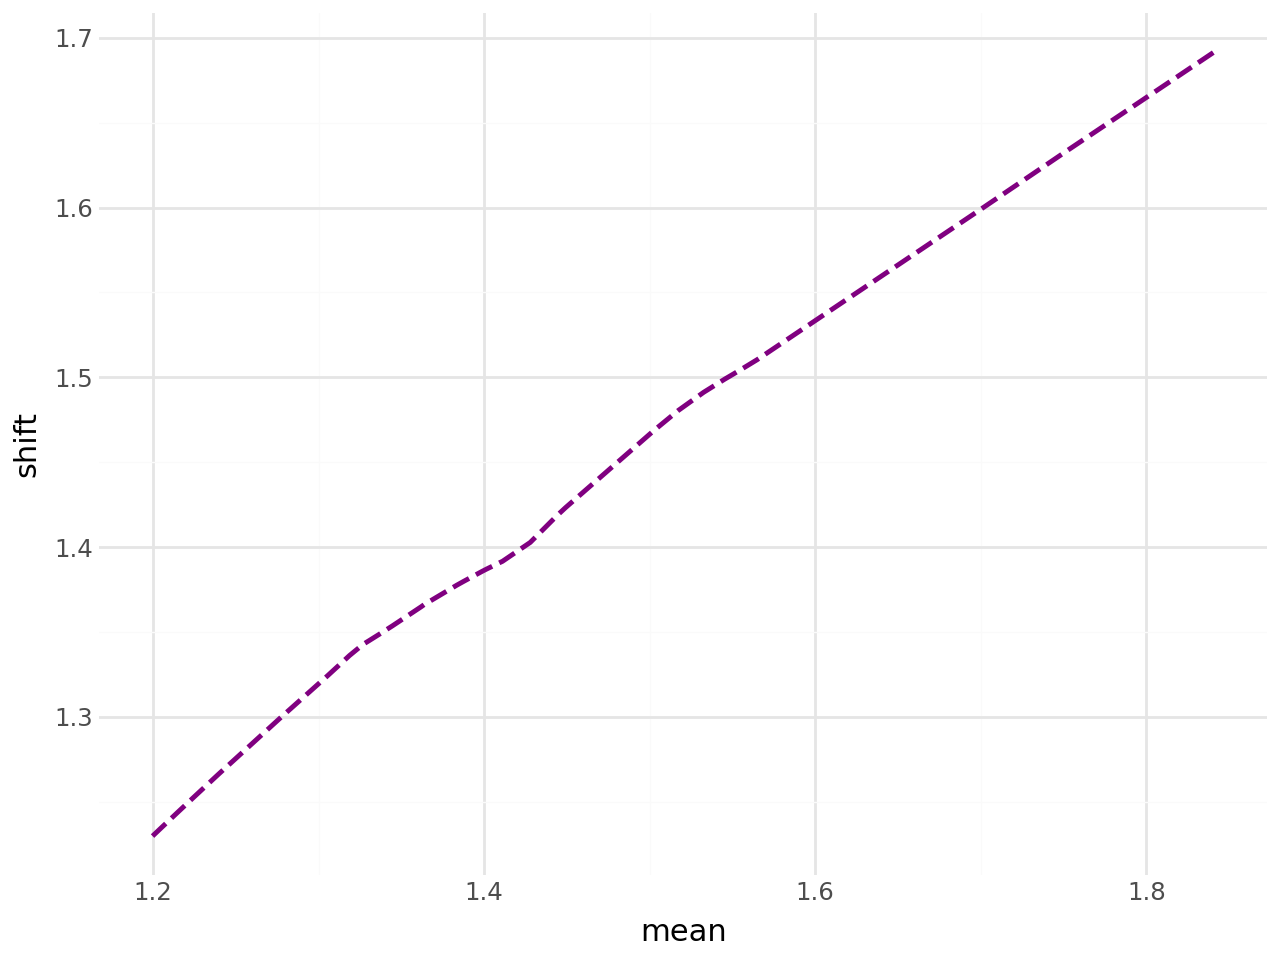

In [235]:
(ggplot(avocado_monthly, aes("mean", "shift"))
 + geom_smooth(linetype="--", color="purple") 
 + theme_minimal())

# STATIONARITY


In [236]:
from statsmodels.tsa.stattools import adfuller

avocado_prices = avocado_monthly[["mean"]]
avocado_prices.head()

,mean
date,
2015-01-31,1.365046
2015-02-28,1.326944
2015-03-31,1.361981
2015-04-30,1.383449
2015-05-31,1.344685


In [237]:
avocado_price_adfuller = adfuller(avocado_prices)
avocado_price_adfuller

(np.float64(-2.9864634051552885),
 np.float64(0.03617803177626096),
 1,
 37,
 {'1%': np.float64(-3.6209175221605827),
  '5%': np.float64(-2.9435394610388332),
  '10%': np.float64(-2.6104002410518627)},
 np.float64(-53.78482395248845))

In [238]:
avocado_price_adfuller = adfuller(avocado_prices)

pd.Series(avocado_price_adfuller[0:5], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used', "Critical Value"])

Test Statistic                                                         -2.986463
p-value                                                                 0.036178
#Lags Used                                                                     1
Number of Observations Used                                                   37
Critical Value                 {'1%': -3.6209175221605827, '5%': -2.943539461...
dtype: object

# AUTOCORRELATION PLOT


In [239]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

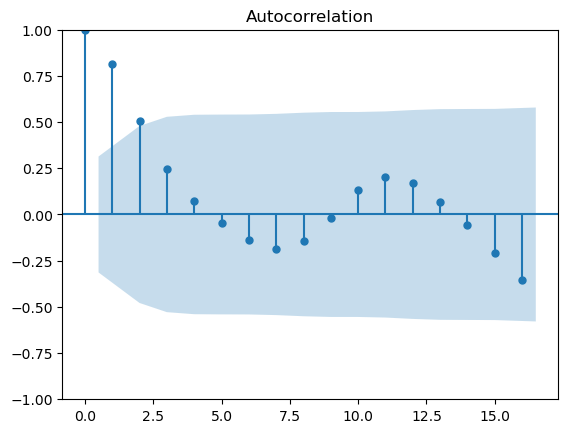

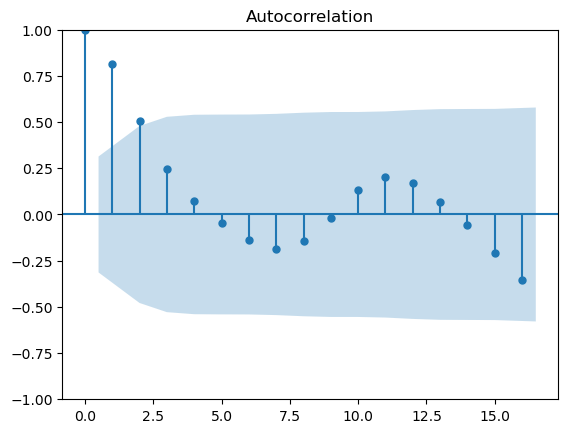

In [240]:
plot_acf(avocado_prices)

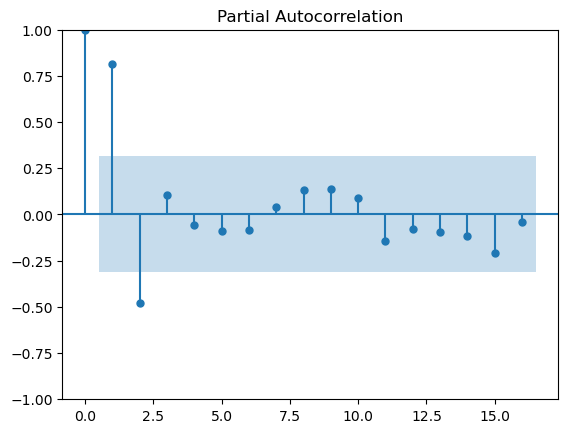

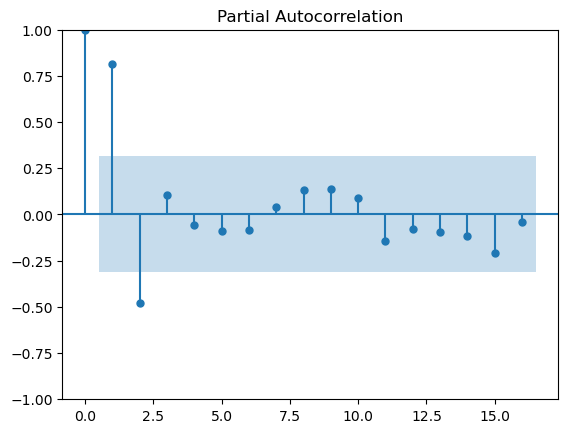

In [241]:
plot_pacf(avocado_prices)

# DECOMPOSITION PLOT

In [242]:
from statsmodels.tsa.seasonal import seasonal_decompose, STL

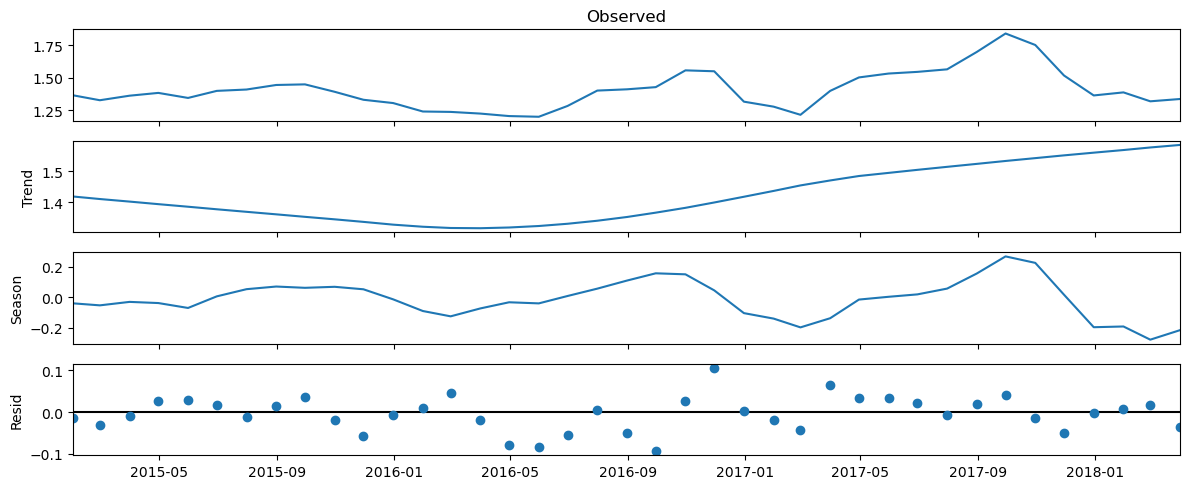

In [243]:
Avocado_stl = STL(avocado_prices)

Avocado_fit = Avocado_stl.fit()

result = Avocado_fit.plot()

result.set_size_inches(12, 5)

result.tight_layout()

plt.show() 

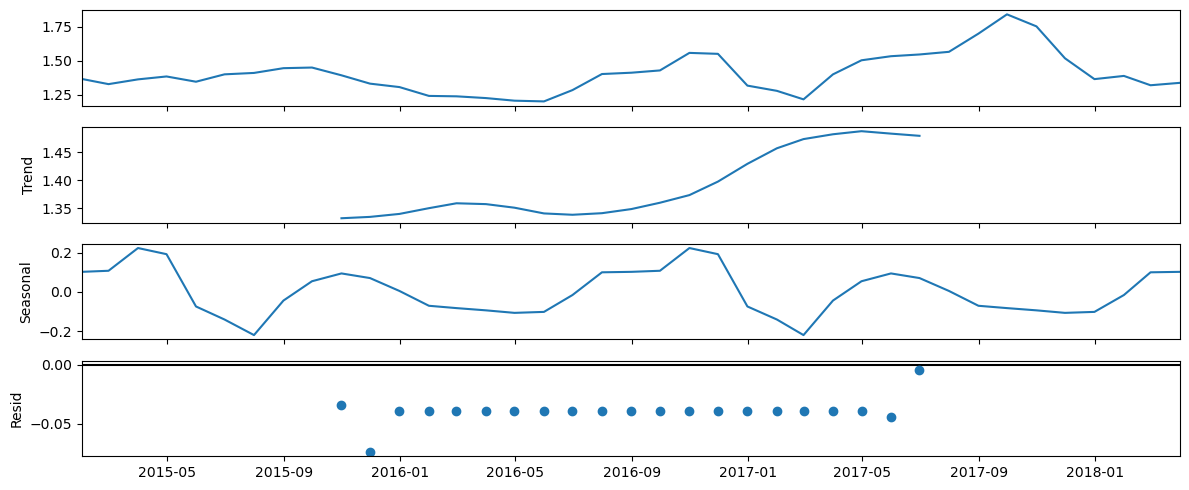

In [244]:
avocado_season = seasonal_decompose(avocado_prices, period = 19)

avocado_plot = avocado_season.plot()

avocado_plot.set_size_inches(12, 5)

avocado_plot.tight_layout()

plt.show()

# SPLITTING AND TRAINING 

In [245]:
avocado_prices.head()

,mean
date,
2015-01-31,1.365046
2015-02-28,1.326944
2015-03-31,1.361981
2015-04-30,1.383449
2015-05-31,1.344685


In [246]:
avocado_prices = avocado_prices.sort_index()
avocado_prices_train = avocado_prices.loc[:"2022-05-17 19:00:00"]
avocado_prices_test = avocado_prices.loc["2022-05-17 20:00:00":]

avocado_prices_train.head()

,mean
date,
2015-01-31,1.365046
2015-02-28,1.326944
2015-03-31,1.361981
2015-04-30,1.383449
2015-05-31,1.344685


# model 1

In [247]:
from statsmodels.tsa.arima.model import ARIMA

In [248]:
price_model = ARIMA(avocado_prices_train, order = (1,0,0))
price_ar1 = price_model.fit()

print(price_ar1.summary())

                               SARIMAX Results                                
Dep. Variable:                   mean   No. Observations:                   39
Model:                 ARIMA(1, 0, 0)   Log Likelihood                  41.084
Date:                Mon, 20 Apr 2026   AIC                            -76.169
Time:                        09:16:56   BIC                            -71.178
Sample:                    01-31-2015   HQIC                           -74.378
                         - 03-31-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3961      0.080     17.495      0.000       1.240       1.553
ar.L1          0.8024      0.079     10.219      0.000       0.649       0.956
sigma2         0.0069      0.001      4.805      0.0

# model2

In [249]:
price_model2 = ARIMA(avocado_prices_train, order = (2,0,0))
price_ar2 = price_model2.fit()

print(price_ar2.summary())

                               SARIMAX Results                                
Dep. Variable:                   mean   No. Observations:                   39
Model:                 ARIMA(2, 0, 0)   Log Likelihood                  45.874
Date:                Mon, 20 Apr 2026   AIC                            -83.748
Time:                        09:16:56   BIC                            -77.094
Sample:                    01-31-2015   HQIC                           -81.361
                         - 03-31-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.4053      0.048     29.222      0.000       1.311       1.500
ar.L1          1.1828      0.170      6.953      0.000       0.849       1.516
ar.L2         -0.4591      0.201     -2.281      0.0

# MODEL EVALUATION

In [259]:
avocado_train_predict = price_ar1.predict(start = avocado_prices_train.index[0],
                                 end = avocado_prices_train.index[-1],
                                 dynamic = False)

avocado_train_predict1 = avocado_train_predict.reset_index()
avocado_train_predict1.head()

,date,predicted_mean
0,2015-01-31,1.396126
1,2015-02-28,1.371188
2,2015-03-31,1.340615
3,2015-04-30,1.368729
4,2015-05-31,1.385954


In [260]:
avocado_train1 = avocado_prices_train.reset_index()

In [261]:
avocado_train_predict1["actual_price"] = avocado_train2["mean"]

avocado_train_predict1.head()

,date,predicted_mean,actual_price
0,2015-01-31,1.396126,1.365046
1,2015-02-28,1.371188,1.326944
2,2015-03-31,1.340615,1.361981
3,2015-04-30,1.368729,1.383449
4,2015-05-31,1.385954,1.344685


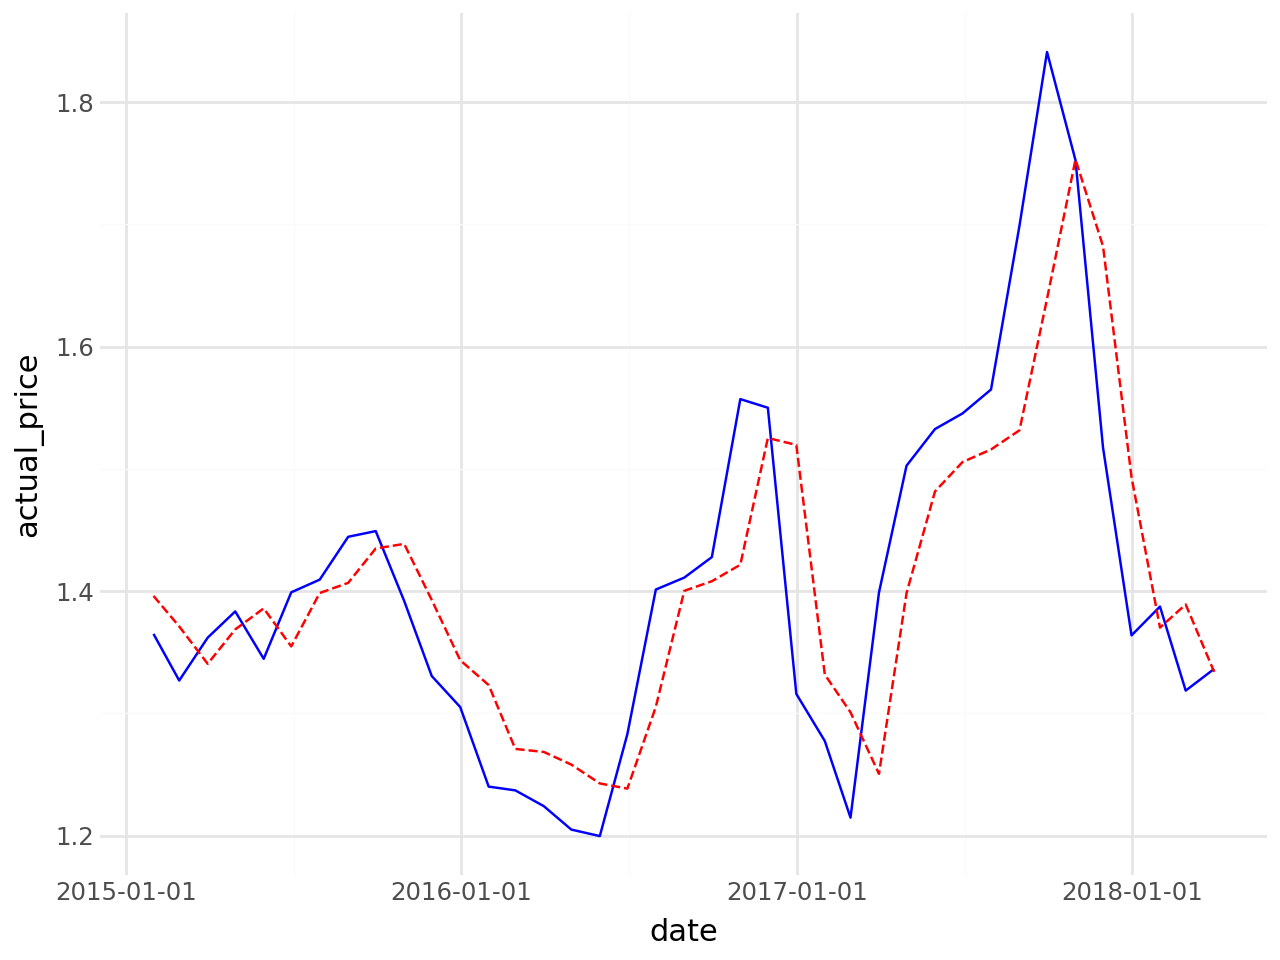

In [262]:
(ggplot(avocado_train_predict1, aes("date", "actual_price"))
+ geom_line(color = "blue")
+ geom_line(aes("date", "predicted_mean"), color = "red", linetype = "--") 
+ theme_minimal())

In [263]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

In [264]:
mse = mean_squared_error(avocado_train_predict2["actual_price"], avocado_train_predict1["predicted_mean"])
print(mse)

rmse = np.sqrt(mse)
print(rmse)

0.006950521395379615
0.08336978706569674


In [265]:
mse = mean_squared_error(avocado_train_predict2["actual_price"], avocado_train_predict1["predicted_mean"])

mse

0.006950521395379615

In [266]:
rmse = np.sqrt(mse)
rmse

np.float64(0.08336978706569674)

In [267]:
mae = mean_absolute_error(avocado_train_predict2["actual_price"], avocado_train_predict2["predicted_mean"])
mae

0.056516698710043285

# MODEL EVALAUATION AND CONCLUSION
The Time Series model performed better than the Linear Regression model, as it achieved a significantly lower RMSE (0.0833 vs 0.3953), indicating more accurate predictions. This suggests that the data contains time-dependent patterns that the Time Series model was able to capture more effectively, while the Linear Regression model could not. Therefore, the Time Series model is the more suitable choice for this analysis.